In [13]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from typing import Callable
import optax

import pcx as px
import pcx.predictive_coding as pxc
import pcx.nn as pxnn
import pcx.functional as pxf
import pcx.utils as pxu

px.RKG.seed(42)

## PART 1: Three-Layer Model on Two Moons with Different ODE Solvers

The inference phase in PCNs can be viewed as solving an ODE:

$$\frac{dh}{dt} = -\frac{\partial E}{\partial h}$$

Different optimizers correspond to different numerical integration schemes:
- **SGD**: Euler method (overdamped dynamics)
- **SGD+Momentum**: Heavy ball method (underdamped dynamics with friction)
- **Nesterov**: Symplectic integrator (preserves energy better)
- **SGLD**: Langevin dynamics (adds thermal noise for exploration)

In [14]:
class ThreeLayerPC(pxc.EnergyModule):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, act_fn: Callable):
        super().__init__()
        self.act_fn = px.static(act_fn)
        
        self.layers = [
            pxnn.Linear(input_dim, hidden_dim),
            pxnn.Linear(hidden_dim, hidden_dim),
            pxnn.Linear(hidden_dim, output_dim)
        ]
        
        self.vodes = [
            pxc.Vode(energy_fn=pxc.se_energy),
            pxc.Vode(energy_fn=pxc.se_energy),
            pxc.Vode(energy_fn=pxc.ce_energy)
        ]
        self.vodes[-1].h.frozen = True
    
    def __call__(self, x, y=None):
        for vode, layer in zip(self.vodes[:-1], self.layers[:-1]):
            x = vode(self.act_fn(layer(x)))
        x = self.vodes[-1](self.layers[-1](x))
        if y is not None:
            self.vodes[-1].set("h", y)
        return self.vodes[-1].get("u")

In [15]:
# Define batched operations
@pxf.vmap(pxu.M(pxc.VodeParam | pxc.VodeParam.Cache).to((None, 0)), in_axes=(0, 0), out_axes=0)
def forward(x, y, *, model):
    return model(x, y)

@pxf.vmap(pxu.M(pxc.VodeParam | pxc.VodeParam.Cache).to((None, 0)), in_axes=(0,), out_axes=(None, 0), axis_name="batch")
def energy(x, *, model):
    y_pred = model(x, None)
    return jax.lax.psum(model.energy(), "batch"), y_pred

In [16]:
# Training function that returns energy history during inference
@pxf.jit(static_argnums=0)
def train_on_batch_with_history(T: int, x: jax.Array, y: jax.Array, *, model, optim_h, optim_w):
    model.train()
    
    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        forward(x, y, model=model)
    
    optim_h.init(pxu.M_hasnot(pxc.VodeParam, frozen=True)(model))
    
    # Pre-allocate array for energy trajectory
    energy_trajectory = jnp.zeros(T)
    
    # Inference loop - manually track energies
    for t in range(T):
        with pxu.step(model, clear_params=pxc.VodeParam.Cache):
            (e, _), g = pxf.value_and_grad(
                pxu.M_hasnot(pxc.VodeParam, frozen=True).to([False, True]), has_aux=True
            )(energy)(x, model=model)
        
        # Store energy at this timestep
        energy_trajectory = energy_trajectory.at[t].set(e)
        
        # Update states
        optim_h.step(model, g["model"])
    
    optim_h.clear()
    
    # Learning phase
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        (e, _), g = pxf.value_and_grad(pxu.M(pxnn.LayerParam).to([False, True]), has_aux=True)(energy)(x, model=model)
    optim_w.step(model, g["model"], scale_by=1.0/x.shape[0])
    
    return energy_trajectory

In [17]:
# Generate Two Moons dataset (full batch)
n_samples = 512
X, y = make_moons(n_samples=n_samples, noise=0.2, random_state=42)
X_train = jnp.array(X)
y_train = jax.nn.one_hot(y, 2)

print(f"Dataset: {X_train.shape[0]} samples, full batch training")

Dataset: 512 samples, full batch training


In [18]:
# Define 4 optimizers from a physics/ODE perspective:
#
# 1. SGD (Euler method): dh/dt = -∇E
#    - Simplest discretization, can be unstable for stiff systems
#
# 2. SGD + Momentum (Heavy Ball): dh/dt = v, dv/dt = -∇E - γv
#    - Models inertia with friction, smoother trajectories
#
# 3. Nesterov (Symplectic-like): Look-ahead gradient evaluation
#    - Better energy preservation, accelerated convergence
#
# 4. Damped Harmonic (High momentum, low lr): Critically damped oscillator
#    - Balances speed and stability, minimal oscillation

optimizer_configs = {
    "SGD (Euler)": lambda: optax.sgd(5e-3),
    "Momentum (Heavy Ball)": lambda: optax.sgd(5e-3, momentum=0.9),
    "Nesterov (Symplectic)": lambda: optax.sgd(5e-3, momentum=0.9, nesterov=True),
    "Damped Harmonic": lambda: optax.sgd(2e-3, momentum=0.95),
}

In [19]:
# Train with each optimizer and collect energy histories
n_epochs = 40
T_inference = 32

results = {}

for name, optim_fn in optimizer_configs.items():
    print(f"\nTraining with {name}...")
    px.RKG.seed(42)
    
    model = ThreeLayerPC(input_dim=2, hidden_dim=32, output_dim=2, act_fn=jax.nn.tanh)
    
    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        forward(X_train, None, model=model)
    
    optim_h = pxu.Optim(optim_fn)
    optim_w = pxu.Optim(lambda: optax.adamw(1e-2), pxu.M(pxnn.LayerParam)(model))
    
    epoch_energies = []
    
    for epoch in range(n_epochs):
        energies = train_on_batch_with_history(
            T_inference, X_train, y_train,
            model=model, optim_h=optim_h, optim_w=optim_w
        )
        epoch_energies.append(np.array(energies))
        print(f"  Epoch {epoch+1}: Final energy = {energies[-1]:.2f}")
    
    results[name] = np.array(epoch_energies)


Training with SGD (Euler)...
  Epoch 1: Final energy = 321.75
  Epoch 2: Final energy = 273.58
  Epoch 3: Final energy = 235.08
  Epoch 4: Final energy = 206.05
  Epoch 5: Final energy = 186.34
  Epoch 6: Final energy = 174.07
  Epoch 7: Final energy = 166.35
  Epoch 8: Final energy = 160.52
  Epoch 9: Final energy = 155.06
  Epoch 10: Final energy = 149.60
  Epoch 11: Final energy = 144.56
  Epoch 12: Final energy = 140.83
  Epoch 13: Final energy = 139.46
  Epoch 14: Final energy = 140.83
  Epoch 15: Final energy = 143.91
  Epoch 16: Final energy = 146.49
  Epoch 17: Final energy = 146.86
  Epoch 18: Final energy = 144.92
  Epoch 19: Final energy = 141.67
  Epoch 20: Final energy = 138.39
  Epoch 21: Final energy = 135.84
  Epoch 22: Final energy = 134.27
  Epoch 23: Final energy = 133.37
  Epoch 24: Final energy = 132.66
  Epoch 25: Final energy = 131.70
  Epoch 26: Final energy = 130.31
  Epoch 27: Final energy = 128.61
  Epoch 28: Final energy = 126.89
  Epoch 29: Final energy = 

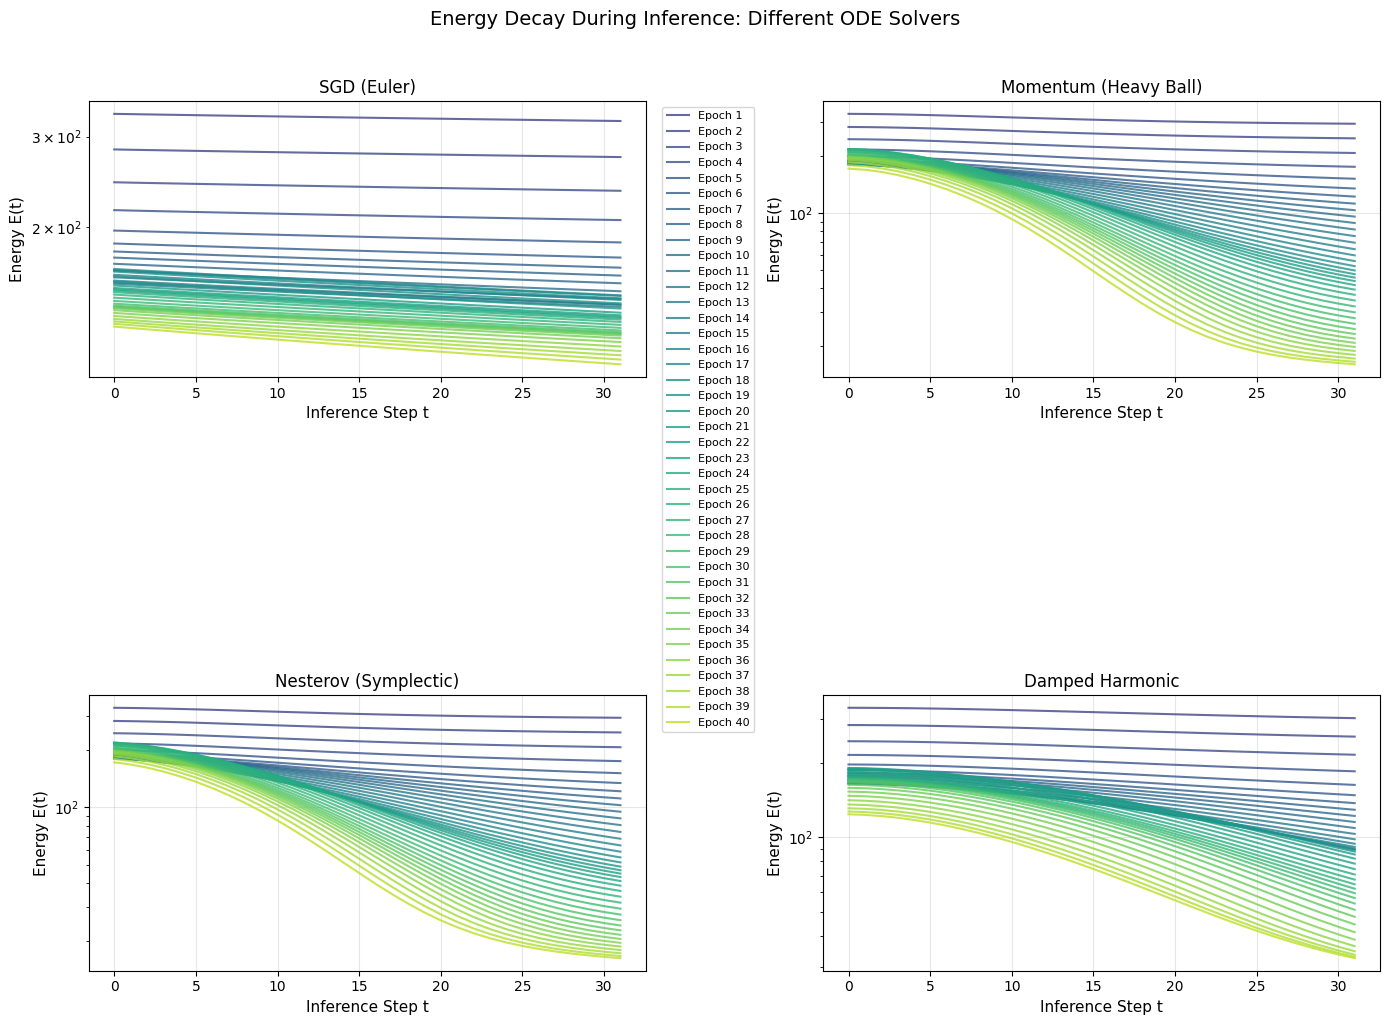


Observations:
• SGD (Euler): Steady decay, but can be slow for complex landscapes
• Momentum: Faster initial decay, may overshoot and oscillate
• Nesterov: Accelerated convergence with look-ahead correction
• Damped Harmonic: Smooth approach to equilibrium, minimal oscillation


In [20]:
# Plot energy decay for each optimizer across epochs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, n_epochs))

for idx, (name, energies) in enumerate(results.items()):
    ax = axes[idx]
    for epoch in range(n_epochs):
        ax.plot(energies[epoch], color=colors[epoch], alpha=0.8, 
                label=f'Epoch {epoch+1}' if idx == 0 else None)
    ax.set_xlabel('Inference Step t', fontsize=11)
    ax.set_ylabel('Energy E(t)', fontsize=11)
    ax.set_title(f'{name}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.suptitle('Energy Decay During Inference: Different ODE Solvers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("• SGD (Euler): Steady decay, but can be slow for complex landscapes")
print("• Momentum: Faster initial decay, may overshoot and oscillate")
print("• Nesterov: Accelerated convergence with look-ahead correction")
print("• Damped Harmonic: Smooth approach to equilibrium, minimal oscillation")

## PART 2: Scaling to MNIST

In [21]:
# Load MNIST
from sklearn.datasets import fetch_openml

print("Loading MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_mnist = mnist.data.astype(np.float32) / 255.0
y_mnist = mnist.target.astype(np.int32)

# Train/test split
X_train_mnist, y_train_mnist = X_mnist[:60000], y_mnist[:60000]
X_test_mnist, y_test_mnist = X_mnist[60000:], y_mnist[60000:]

print(f"Train: {X_train_mnist.shape}, Test: {X_test_mnist.shape}")

Loading MNIST...


Train: (60000, 784), Test: (10000, 784)


In [22]:
# Prepare batched data
batch_size = 128
n_train = (len(X_train_mnist) // batch_size) * batch_size
n_test = (len(X_test_mnist) // batch_size) * batch_size

X_train_batches = X_train_mnist[:n_train].reshape(-1, batch_size, 784)
y_train_batches = y_train_mnist[:n_train].reshape(-1, batch_size)
X_test_batches = X_test_mnist[:n_test].reshape(-1, batch_size, 784)
y_test_batches = y_test_mnist[:n_test].reshape(-1, batch_size)

print(f"Training batches: {X_train_batches.shape[0]}, Test batches: {X_test_batches.shape[0]}")

Training batches: 468, Test batches: 78


In [23]:
# Standard training function
@pxf.jit(static_argnums=0)
def train_step(T, x, y, *, model, optim_h, optim_w):
    model.train()
    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        forward(x, y, model=model)
    optim_h.init(pxu.M_hasnot(pxc.VodeParam, frozen=True)(model))
    
    for _ in range(T):
        with pxu.step(model, clear_params=pxc.VodeParam.Cache):
            (e, _), g = pxf.value_and_grad(
                pxu.M_hasnot(pxc.VodeParam, frozen=True).to([False, True]), has_aux=True
            )(energy)(x, model=model)
        optim_h.step(model, g["model"])
    optim_h.clear()
    
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        (e, _), g = pxf.value_and_grad(pxu.M(pxnn.LayerParam).to([False, True]), has_aux=True)(energy)(x, model=model)
    optim_w.step(model, g["model"], scale_by=1.0/x.shape[0])

@pxf.jit()
def eval_batch(x, y, *, model):
    model.eval()
    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        y_pred = forward(x, None, model=model).argmax(axis=-1)
    return (y_pred == y).sum()

In [24]:
# Train MNIST with all optimizers
n_epochs = 40
T_inference = 12

mnist_results = {}

for name, optim_fn in optimizer_configs.items():
    print(f"\n{'='*50}")
    print(f"Training MNIST with {name}")
    print('='*50)
    
    px.RKG.seed(42)
    model = ThreeLayerPC(input_dim=784, hidden_dim=64, output_dim=10, act_fn=jax.nn.relu)
    
    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        forward(jnp.zeros((batch_size, 784)), None, model=model)
    
    optim_h = pxu.Optim(optim_fn)
    optim_w = pxu.Optim(lambda: optax.adamw(1e-3), pxu.M(pxnn.LayerParam)(model))
    
    first_batch_energies = []
    best_accuracy = 0
    
    for epoch in range(n_epochs):
        # Track energy on first batch
        x_first = X_train_batches[0]
        y_first = jax.nn.one_hot(y_train_batches[0], 10)
        
        epoch_energy = train_on_batch_with_history(
            T_inference, x_first, y_first,
            model=model, optim_h=optim_h, optim_w=optim_w
        )
        first_batch_energies.append(np.array(epoch_energy))
        
        # Train remaining batches
        for i in range(1, len(X_train_batches)):
            train_step(
                T_inference,
                X_train_batches[i],
                jax.nn.one_hot(y_train_batches[i], 10),
                model=model, optim_h=optim_h, optim_w=optim_w
            )
        
        # Evaluate
        correct = sum(eval_batch(X_test_batches[i], y_test_batches[i], model=model) 
                      for i in range(len(X_test_batches)))
        acc = correct / n_test * 100
        if acc > best_accuracy:
            best_accuracy = acc
        print(f"Epoch {epoch+1}: Test Acc = {acc:.2f}%")
    
    final_acc = correct / n_test * 100
    mnist_results[name] = {'energies': np.array(first_batch_energies), 'accuracy': best_accuracy}


Training MNIST with SGD (Euler)
Epoch 1: Test Acc = 94.67%
Epoch 1: Test Acc = 94.67%
Epoch 2: Test Acc = 96.22%
Epoch 2: Test Acc = 96.22%
Epoch 3: Test Acc = 96.22%
Epoch 3: Test Acc = 96.22%
Epoch 4: Test Acc = 96.42%
Epoch 4: Test Acc = 96.42%
Epoch 5: Test Acc = 96.56%
Epoch 5: Test Acc = 96.56%
Epoch 6: Test Acc = 96.31%
Epoch 6: Test Acc = 96.31%
Epoch 7: Test Acc = 96.34%
Epoch 7: Test Acc = 96.34%
Epoch 8: Test Acc = 96.20%
Epoch 8: Test Acc = 96.20%
Epoch 9: Test Acc = 96.10%
Epoch 9: Test Acc = 96.10%
Epoch 10: Test Acc = 95.73%
Epoch 10: Test Acc = 95.73%
Epoch 11: Test Acc = 96.00%
Epoch 11: Test Acc = 96.00%
Epoch 12: Test Acc = 95.94%
Epoch 12: Test Acc = 95.94%
Epoch 13: Test Acc = 95.66%
Epoch 13: Test Acc = 95.66%
Epoch 14: Test Acc = 95.62%
Epoch 14: Test Acc = 95.62%
Epoch 15: Test Acc = 95.73%
Epoch 15: Test Acc = 95.73%
Epoch 16: Test Acc = 95.73%
Epoch 16: Test Acc = 95.73%
Epoch 17: Test Acc = 95.83%
Epoch 17: Test Acc = 95.83%
Epoch 18: Test Acc = 96.01%
Epoch

/tmp/ipykernel_3948953/4195243667.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


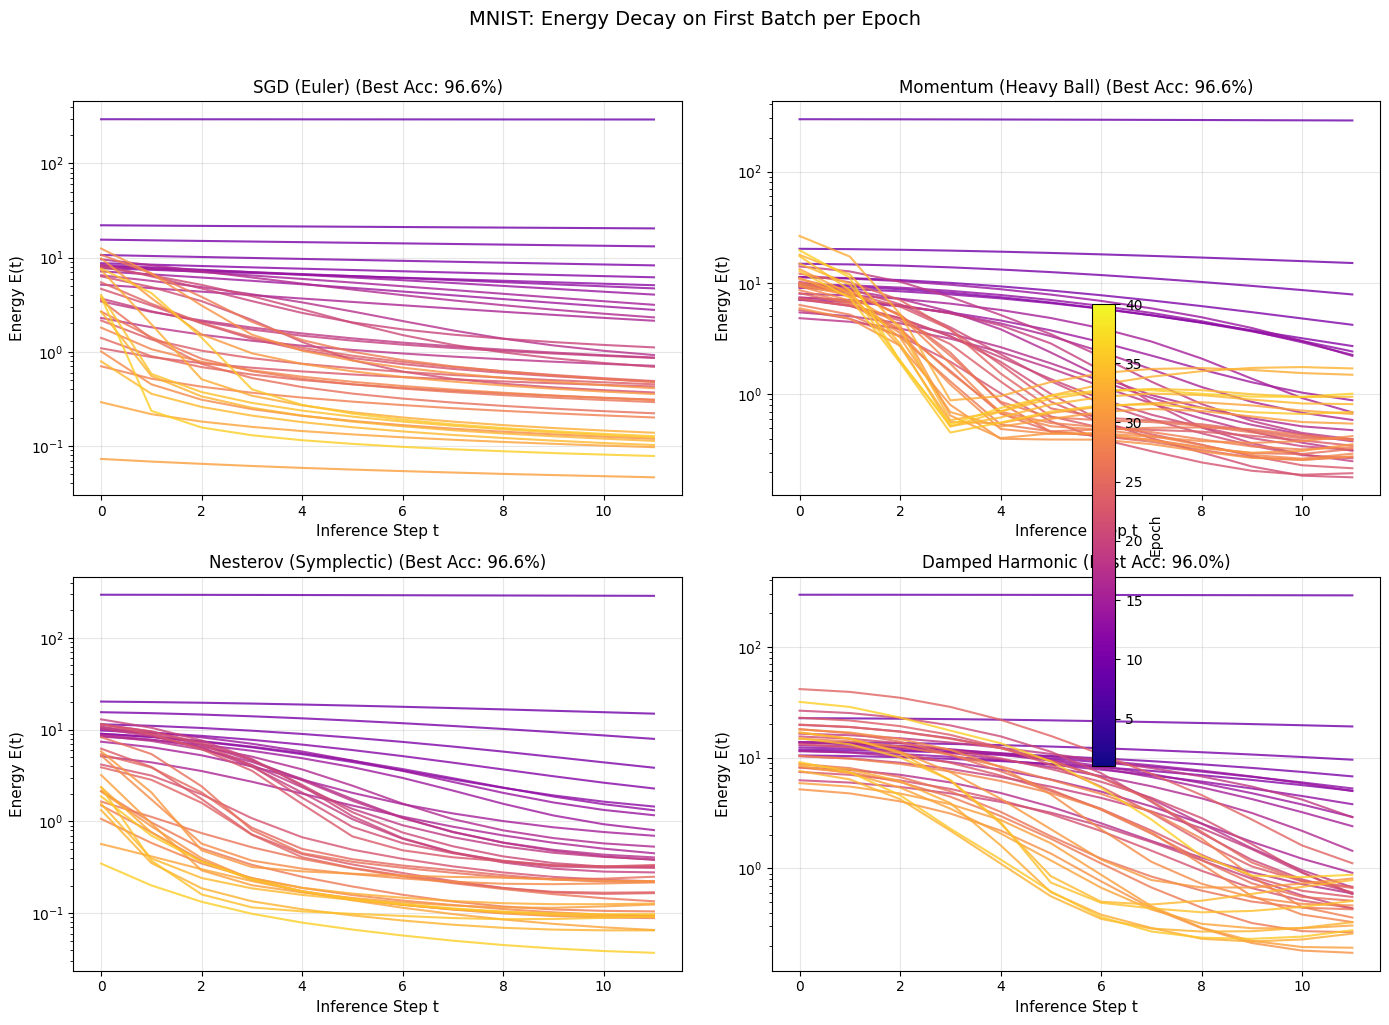

In [25]:
# Plot MNIST results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = plt.cm.plasma(np.linspace(0.2, 0.9, n_epochs))

for idx, (name, data) in enumerate(mnist_results.items()):
    ax = axes[idx]
    for epoch in range(n_epochs):
        ax.plot(data['energies'][epoch], color=colors[epoch], alpha=0.8)
    ax.set_xlabel('Inference Step t', fontsize=11)
    ax.set_ylabel('Energy E(t)', fontsize=11)
    ax.set_title(f'{name} (Best Acc: {data["accuracy"]:.1f}%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(1, n_epochs))
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, label='Epoch')

plt.suptitle('MNIST: Energy Decay on First Batch per Epoch', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# Summary table
print("\n" + "="*60)
print("BEST TEST ACCURACIES")
print("="*60)
print(f"{'Optimizer':<25} {'Accuracy':>15}")
print("-"*40)
for name, data in mnist_results.items():
    print(f"{name:<25} {data['accuracy']:>14.2f}%")
print("="*60)

print("\nKey Insights:")
print("• Momentum methods converge faster in early inference steps")
print("• Nesterov provides acceleration without excessive oscillation")
print("• The damped harmonic approach offers stability for complex data")
print("• Energy decay patterns reveal optimization dynamics at each epoch")


BEST TEST ACCURACIES
Optimizer                        Accuracy
----------------------------------------
SGD (Euler)                        96.56%
Momentum (Heavy Ball)              96.64%
Nesterov (Symplectic)              96.64%
Damped Harmonic                    95.95%

Key Insights:
• Momentum methods converge faster in early inference steps
• Nesterov provides acceleration without excessive oscillation
• The damped harmonic approach offers stability for complex data
• Energy decay patterns reveal optimization dynamics at each epoch
